# End-to-end surrogate — prescribed contour

Section 3.5.1 (*Direct surrogate performance*), Appendix C and the per-checkpoint histograms. Prescribed contours only.


In [1]:
import sys, os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
sys.path.insert(0, os.path.join('..', 'src'))

import glob
import re
import gc
import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from laplace_surrogate.inference.pipeline import InferencePipeline

/users/eleves-b/2023/keyvan.attarian/diffusion_ae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Article figure style; `run` prefixes the output filenames.
import figstyle
figstyle.setup(run='surr')       # titles=True pour garder les suptitle en interactif


figstyle: style=paper.mplstyle  run=surr  titles=suppressed  ->  /users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images


## 1. Dataset loading

In [3]:
DATA_PATH  = '../dataset/ch4_rotated.npy'
DOE_PATH   = '../dataset/doe_rotated.npy'
SPLIT_PATH = '../dataset/split.npz'
CKPT_DIR   = '../checkpoints'
CACHE_DIR  = 'cache_surr'      # separate cache from AE notebook
N          = 128
DT         = 1.0

os.makedirs(CACHE_DIR, exist_ok=True)

# Raw field data (mmap)
U_raw = np.load(DATA_PATH, mmap_mode='r')          # (ns, Nt, H, W)
ns, Nt_full, H, W = U_raw.shape
print(f'Dataset: {ns} sims, Nt={Nt_full}, {H}×{W}')

# Physical parameters θ = (k, A, C)
doe = np.load(DOE_PATH)
theta_np = np.stack([doe['k'], doe['A'], doe['C']], axis=1).astype(np.float32)  # (ns, 3)
print(f'θ shape: {theta_np.shape}  min={theta_np.min():.3f}  max={theta_np.max():.3f}')

# Train/test split
split     = np.load(SPLIT_PATH)
test_idx  = split['test_idx'].tolist()
train_idx = [i for i in range(ns) if i not in set(test_idx)]
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')

Dataset: 8100 sims, Nt=150, 128×128
θ shape: (8100, 3)  min=0.000  max=350.000


Train: 6480  Test: 1620


In [4]:
def load_u(idx: int) -> np.ndarray:
    """Load and resize U to (Nt, N, N) float32."""
    u = U_raw[idx].astype(np.float32)
    if u.shape[-1] != N:
        u_t = torch.from_numpy(u).unsqueeze(1)
        u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
        u   = u_t.squeeze(1).numpy()
    return u

## 2. Evaluation function

`InferencePipeline` handles all model types transparently.

In [5]:
def eval_surrogate(ckpt_path: str, idx_list: list, device='cpu', batch_size: int = 32) -> np.ndarray:
    """
    Computes L2rel (%) on physical field U for every simulation in idx_list.
    Uses InferencePipeline so it works for any surrogate type.
    Returns np.ndarray of shape (n_samples,).
    """
    pipe = InferencePipeline.from_checkpoint(ckpt_path, device=device)
    name = os.path.basename(ckpt_path)

    l2rel_list = []
    for start in tqdm(range(0, len(idx_list), batch_size), desc=name, leave=False):
        batch_idx = idx_list[start:start + batch_size]
        theta_batch = theta_np[batch_idx]         # (B, 3)
        U_pred = pipe.predict(theta_batch)         # (B, Nt, N, N)

        for j, idx in enumerate(batch_idx):
            U_gt   = load_u(idx)                   # (Nt, N, N)
            denom  = np.linalg.norm(U_gt)
            if denom >= 1e-12:
                l2rel_list.append(
                    np.linalg.norm(U_pred[j] - U_gt) / denom * 100.0
                )

        if device == 'cuda':
            torch.cuda.empty_cache()

    pipe.model.cpu()
    del pipe
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return np.array(l2rel_list)

## 3. Evaluate all surrogate checkpoints

In [6]:
def _cache_path(name: str) -> str:
    return os.path.join(CACHE_DIR, f'{name}.npz')

def _cache_valid(cache_file: str, ckpt_path: str) -> bool:
    if not os.path.exists(cache_file):
        return False
    try:
        data = np.load(cache_file, allow_pickle=True)
        return float(data['ckpt_mtime']) == os.path.getmtime(ckpt_path)
    except Exception as e:
        print(f'Failed to load cache {cache_file}: {e}')
        return False

def _save_cache(name: str, ckpt_path: str, l2rel: np.ndarray):
    np.savez(
        _cache_path(name),
        l2rel      = l2rel,
        ckpt_mtime = np.float64(os.path.getmtime(ckpt_path)),
    )

def _load_cache(name: str) -> np.ndarray:
    return np.load(_cache_path(name))['l2rel']


def _model_type_from_ckpt(ckpt_path: str) -> str:
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    return ckpt.get('model_type', 'SLAEModel')


# ── Main loop ────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}\n')

# Surrogate checkpoints are .pt files (AE checkpoints are .ckpt)
# Exclude svd_bases.pt which is not a surrogate
ckpt_paths = sorted([
    p for p in glob.glob(os.path.join(CKPT_DIR, '*.ckpt'))
    if (os.path.basename(p).startswith('SLAEModel') or os.path.basename(p).startswith('LLAEModel'))
        and not ("_ll__" in os.path.basename(p) or "_ol" in os.path.basename(p))
        and not os.path.basename(p).startswith('svd_bases')
])
print(f'{len(ckpt_paths)} surrogate checkpoints found:')
for p in ckpt_paths:
    print(' ', os.path.basename(p))

Device: cuda

14 surrogate checkpoints found:
  LLAEModel__llae_ld128_K16_g0.01__t4h2.ckpt
  LLAEModel__llae_ld32_K16_g0.01__t4h2.ckpt
  LLAEModel__llae_ld64_K16_g0.001__t4h2.ckpt
  LLAEModel__llae_ld64_K16_g0.01__t4h2.ckpt
  LLAEModel__llae_ld64_K16_g0.0__t4h2.ckpt
  LLAEModel__llae_ld64_K32_g0.01__t4h2.ckpt
  LLAEModel__llae_ld64_K8_g0.01__t4h2.ckpt
  SLAEModel__slae_ld128_K16_g0.01__t4h2.ckpt
  SLAEModel__slae_ld32_K16_g0.01__t4h2.ckpt
  SLAEModel__slae_ld64_K16_g0.001__t4h2.ckpt
  SLAEModel__slae_ld64_K16_g0.01__t4h2.ckpt
  SLAEModel__slae_ld64_K16_g0.0__t4h2.ckpt
  SLAEModel__slae_ld64_K32_g0.01__t4h2.ckpt
  SLAEModel__slae_ld64_K8_g0.01__t4h2.ckpt


In [7]:
results     = {}   # name → np.array L2rel (%)
model_types = {}   # name → model_type str

for ckpt_path in ckpt_paths:
    name       = os.path.splitext(os.path.basename(ckpt_path))[0]
    cache_file = _cache_path(name)

    mtype = _model_type_from_ckpt(ckpt_path)
    model_types[name] = mtype

    if _cache_valid(cache_file, ckpt_path):
        l2 = _load_cache(name)
        print(f'[cache]   {name}  [{mtype}]')
    else:
        print(f'[compute] {name}  [{mtype}]')
        try:
            l2 = eval_surrogate(ckpt_path, test_idx, device=device)
            _save_cache(name, ckpt_path, l2)
        except Exception as e:
            print(f'   ERROR: {e}')
            continue

    results[name] = l2
    print(f'   median={np.median(l2):.2f}%  mean={np.mean(l2):.2f}%  '
          f'p90={np.percentile(l2,90):.2f}%  n={len(l2)}')

print('\nDone.')

[cache]   LLAEModel__llae_ld128_K16_g0.01__t4h2  [LLAEModel]
   median=3.84%  mean=4.12%  p90=6.03%  n=1620
[cache]   LLAEModel__llae_ld32_K16_g0.01__t4h2  [LLAEModel]
   median=4.34%  mean=4.71%  p90=7.08%  n=1620
[cache]   LLAEModel__llae_ld64_K16_g0.001__t4h2  [LLAEModel]
   median=4.07%  mean=4.37%  p90=6.48%  n=1620


[cache]   LLAEModel__llae_ld64_K16_g0.01__t4h2  [LLAEModel]
   median=4.06%  mean=4.37%  p90=6.47%  n=1620
[cache]   LLAEModel__llae_ld64_K16_g0.0__t4h2  [LLAEModel]
   median=4.34%  mean=4.68%  p90=6.93%  n=1620
[cache]   LLAEModel__llae_ld64_K32_g0.01__t4h2  [LLAEModel]
   median=4.33%  mean=4.63%  p90=6.79%  n=1620
[cache]   LLAEModel__llae_ld64_K8_g0.01__t4h2  [LLAEModel]
   median=4.01%  mean=4.34%  p90=6.42%  n=1620


[cache]   SLAEModel__slae_ld128_K16_g0.01__t4h2  [SLAEModel]
   median=7.50%  mean=7.67%  p90=9.18%  n=1620
[cache]   SLAEModel__slae_ld32_K16_g0.01__t4h2  [SLAEModel]
   median=7.62%  mean=7.85%  p90=9.49%  n=1620
[cache]   SLAEModel__slae_ld64_K16_g0.001__t4h2  [SLAEModel]
   median=7.43%  mean=7.57%  p90=8.90%  n=1620


[cache]   SLAEModel__slae_ld64_K16_g0.01__t4h2  [SLAEModel]
   median=7.59%  mean=7.87%  p90=9.50%  n=1620
[cache]   SLAEModel__slae_ld64_K16_g0.0__t4h2  [SLAEModel]
   median=7.39%  mean=7.53%  p90=8.81%  n=1620
[cache]   SLAEModel__slae_ld64_K32_g0.01__t4h2  [SLAEModel]
   median=5.70%  mean=6.07%  p90=7.98%  n=1620
[cache]   SLAEModel__slae_ld64_K8_g0.01__t4h2  [SLAEModel]
   median=11.62%  mean=11.89%  p90=13.84%  n=1620

Done.


In [8]:
# ── Plot helpers: palette + human-readable checkpoint names ──────────────
from matplotlib.patches import Patch

# Keyed by the `model_type` stored in the checkpoint (see InferencePipeline).
# SLAE family → blues, LLAE family → warm tones.
PALETTE = dict(figstyle.MODEL_COLORS)   # palette partagee — voir notebooks/figstyle.py

# AE stem, e.g. 'llae_ld64_K16_g0.01' or 'slae_ld64_K16_g0.0_ol'
_AE_STEM_PAT = re.compile(
    r'^(?P<ae>slae|llae|lslae)_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<ae_suf>.*)$'
)

# Surrogate ckpt, e.g. 'LLAETuckerModel__llae_ld64_K16_g0.01__t4h2_rs8rz16[-v1]'
_SURR_PAT = re.compile(
    r'^(?P<cls>[A-Za-z]+Model)__(?P<ae_stem>.+?)__'
    r't(?P<n_trunk>\d+)h(?P<n_head>\d+)(?P<suffix>.*?)(?:-v(?P<ver>\d+))?$'
)


def _fmt_g(g: str) -> str:
    f = float(g)
    return str(int(f)) if f == int(f) else str(f)


def _pretty_name(name: str) -> str:
    """'LLAETuckerModel__llae_ld64_K16_g0.01__t4h2_rs8rz16' →
       'LLAE-Tucker  d=64, K=16, γ=0.01\nt4h2  r_s=8, r_z=16'

    Checkpoints with a fitted Laplace basis (_ll / _ol) show the tag instead of γ."""
    m = _SURR_PAT.match(name)
    if not m:
        return name
    sm = _AE_STEM_PAT.match(m.group('ae_stem'))
    if not sm:
        return name

    cls   = m.group('cls')
    label = 'LLAE' if cls.startswith('LLAE') else 'SLAE'
    if 'Tucker' in cls:
        label += '-Tucker'
    elif 'SVD' in cls:
        label += '-SVD'

    # With a learnable/optimised Laplace basis (_ll / _ol) the poles are fitted,
    # so gamma_init is meaningless and is replaced by the basis tag.
    head   = f"{label}  d={sm.group('ld')}, K={sm.group('K')}"
    ae_suf = sm.group('ae_suf').strip('_')
    if ae_suf:
        head += f' [{ae_suf}]'
    else:
        head += f", γ={_fmt_g(sm.group('g'))}"

    suffix = m.group('suffix')
    bits   = [f"t{m.group('n_trunk')}h{m.group('n_head')}"]
    rank = re.search(r'rs(\d+)rz(\d+)', suffix)
    if rank:
        bits.append(f'r_s={rank.group(1)}, r_z={rank.group(2)}')
    if m.group('ver'):
        bits.append(f"v{m.group('ver')}")

    return head + '\n' + '  '.join(bits)


## 4. Laplace poles $s_k$ and inversion regularization

Direct surrogates only (`SLAEModel` / `LLAEModel`). Everything is read from the
loaded models (`pipe.model.laplace`): the poles $s_k = \sigma_k + i\omega_k$ actually
used at inference, their initialization buffers, and the effective inversion
regularization $\alpha_t$ (temporal smoothing) and $\lambda$ (ridge).
One figure per family, one panel per checkpoint.


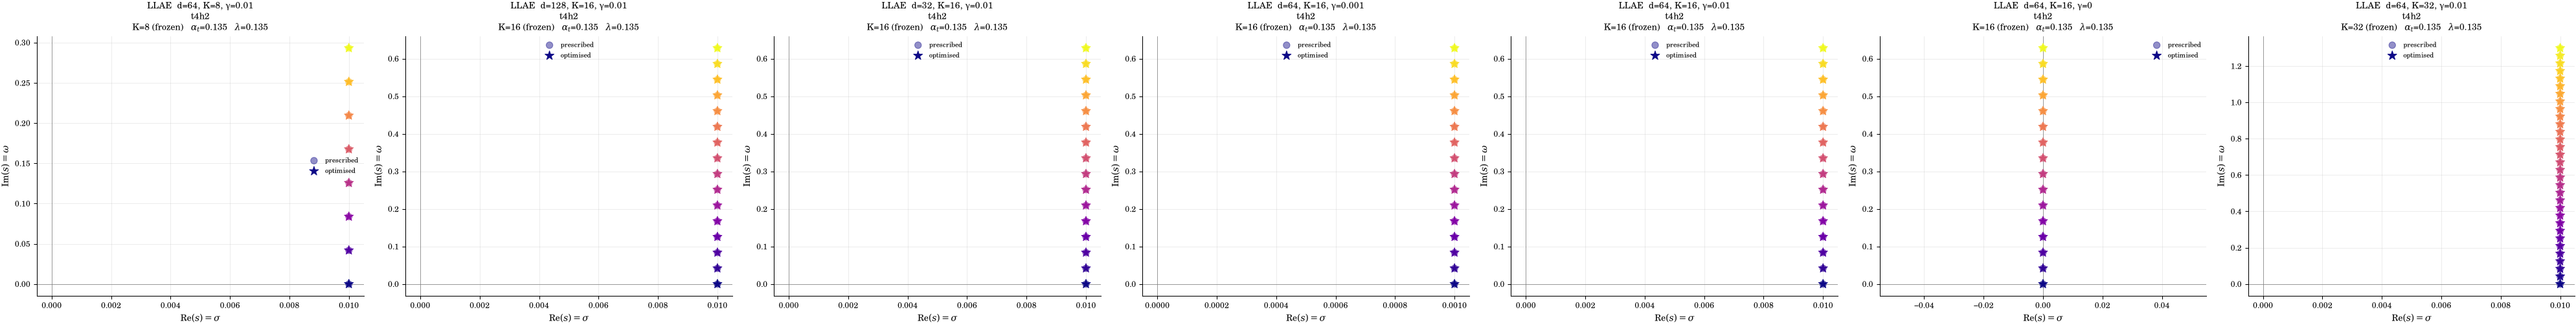

  ↳ article/images/surr_contour_poles_llae.pdf


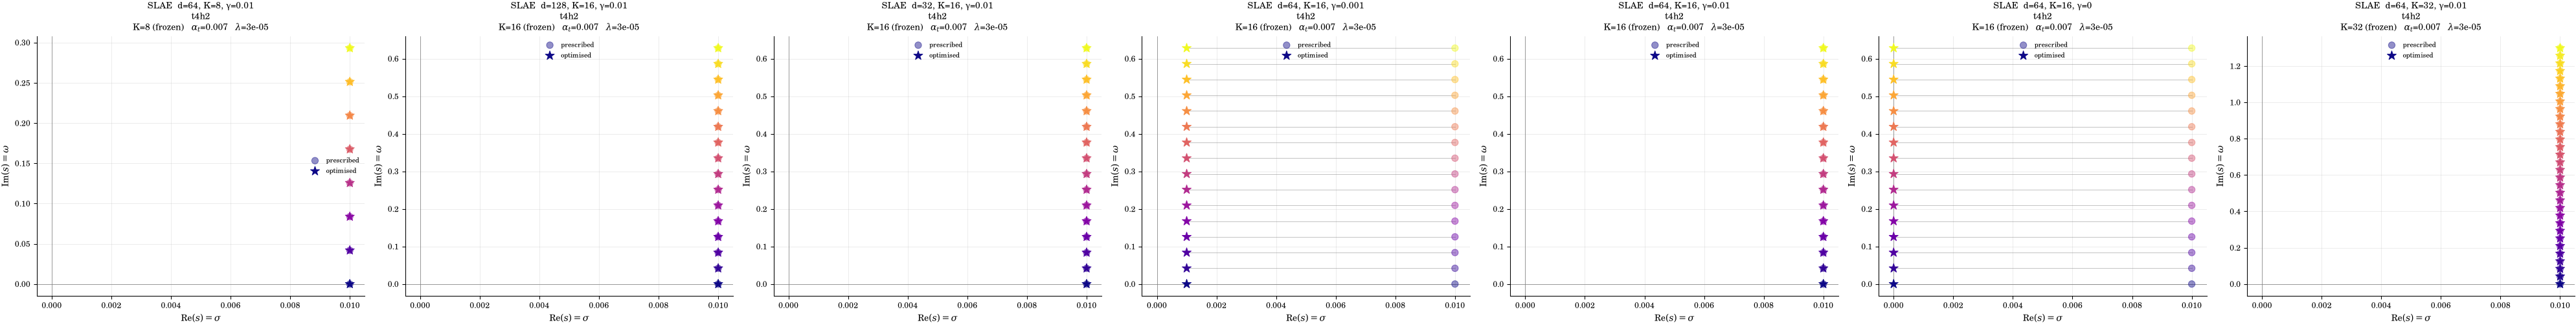

  ↳ article/images/surr_contour_poles_slae.pdf


In [9]:
# ── Laplace poles s_k + regularization of the direct surrogates ──────────
pole_info = {}   # name → dict

for ckpt_path in ckpt_paths:
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    if model_types.get(name) not in ('SLAEModel', 'LLAEModel'):
        continue
    pipe = InferencePipeline.from_checkpoint(ckpt_path, device='cpu')
    lap  = pipe.model.laplace
    with torch.no_grad():
        alpha_t = lap.log_alpha_t.exp() if lap.learnable else lap._alpha_t_fixed
        lam     = lap.log_lam.exp()     if lap.learnable else lap._lam_fixed
        pole_info[name] = dict(
            s_cur     = lap.s_list.detach().numpy().copy(),
            s_init    = (lap._s_init_re + 1j * lap._s_init_im).numpy().copy(),
            alpha_t   = float(alpha_t),
            lam       = float(lam),
            learnable = bool(lap.learnable),
            mtype     = pipe.model_type,
        )
    del pipe
gc.collect()

for family in ('LLAEModel', 'SLAEModel'):
    names = sorted(
        [n for n in pole_info if pole_info[n]['mtype'] == family],
        key=lambda n: (len(pole_info[n]['s_cur']), n),
    )
    if not names:
        print(f'No {family} checkpoint found.')
        continue

    fig, axes = plt.subplots(1, len(names), figsize=(5.2 * len(names), 4.8), squeeze=False)
    for ax, n in zip(axes[0], names):
        info = pole_info[n]
        s_cur, s_ini = info['s_cur'], info['s_init']
        K = len(s_cur)
        c = np.arange(K)
        for a, b in zip(s_ini, s_cur):
            ax.plot([a.real, b.real], [a.imag, b.imag], color='gray', lw=0.6, alpha=0.5, zorder=1)
        ax.scatter(s_ini.real, s_ini.imag, c=c, cmap='plasma', s=45, marker='o',
                   alpha=0.45, zorder=3, label='prescribed')
        ax.scatter(s_cur.real, s_cur.imag, c=c, cmap='plasma', s=90, marker='*',
                   zorder=4, label='optimised')
        ax.axvline(0, color='gray', lw=0.5)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_xlabel(r'Re$(s) = \sigma$')
        ax.set_ylabel(r'Im$(s) = \omega$')
        tag = 'learnable' if info['learnable'] else 'frozen'
        ax.set_title(
            _pretty_name(n) + '\n'
            + rf'K={K} ({tag})   $\alpha_t$={info["alpha_t"]:.3g}   $\lambda$={info["lam"]:.3g}',
            fontsize=9,
        )
        ax.grid(alpha=0.3)
        ax.legend(fontsize=7)

    fig.suptitle(f'{family} — Laplace poles $s_k$ and inversion regularization',
                 fontweight='bold')
    fig.tight_layout()
    plt.show()
    figstyle.save("contour_poles_" + str(family).replace("Model", "").lower())


## 5. Histograms per checkpoint

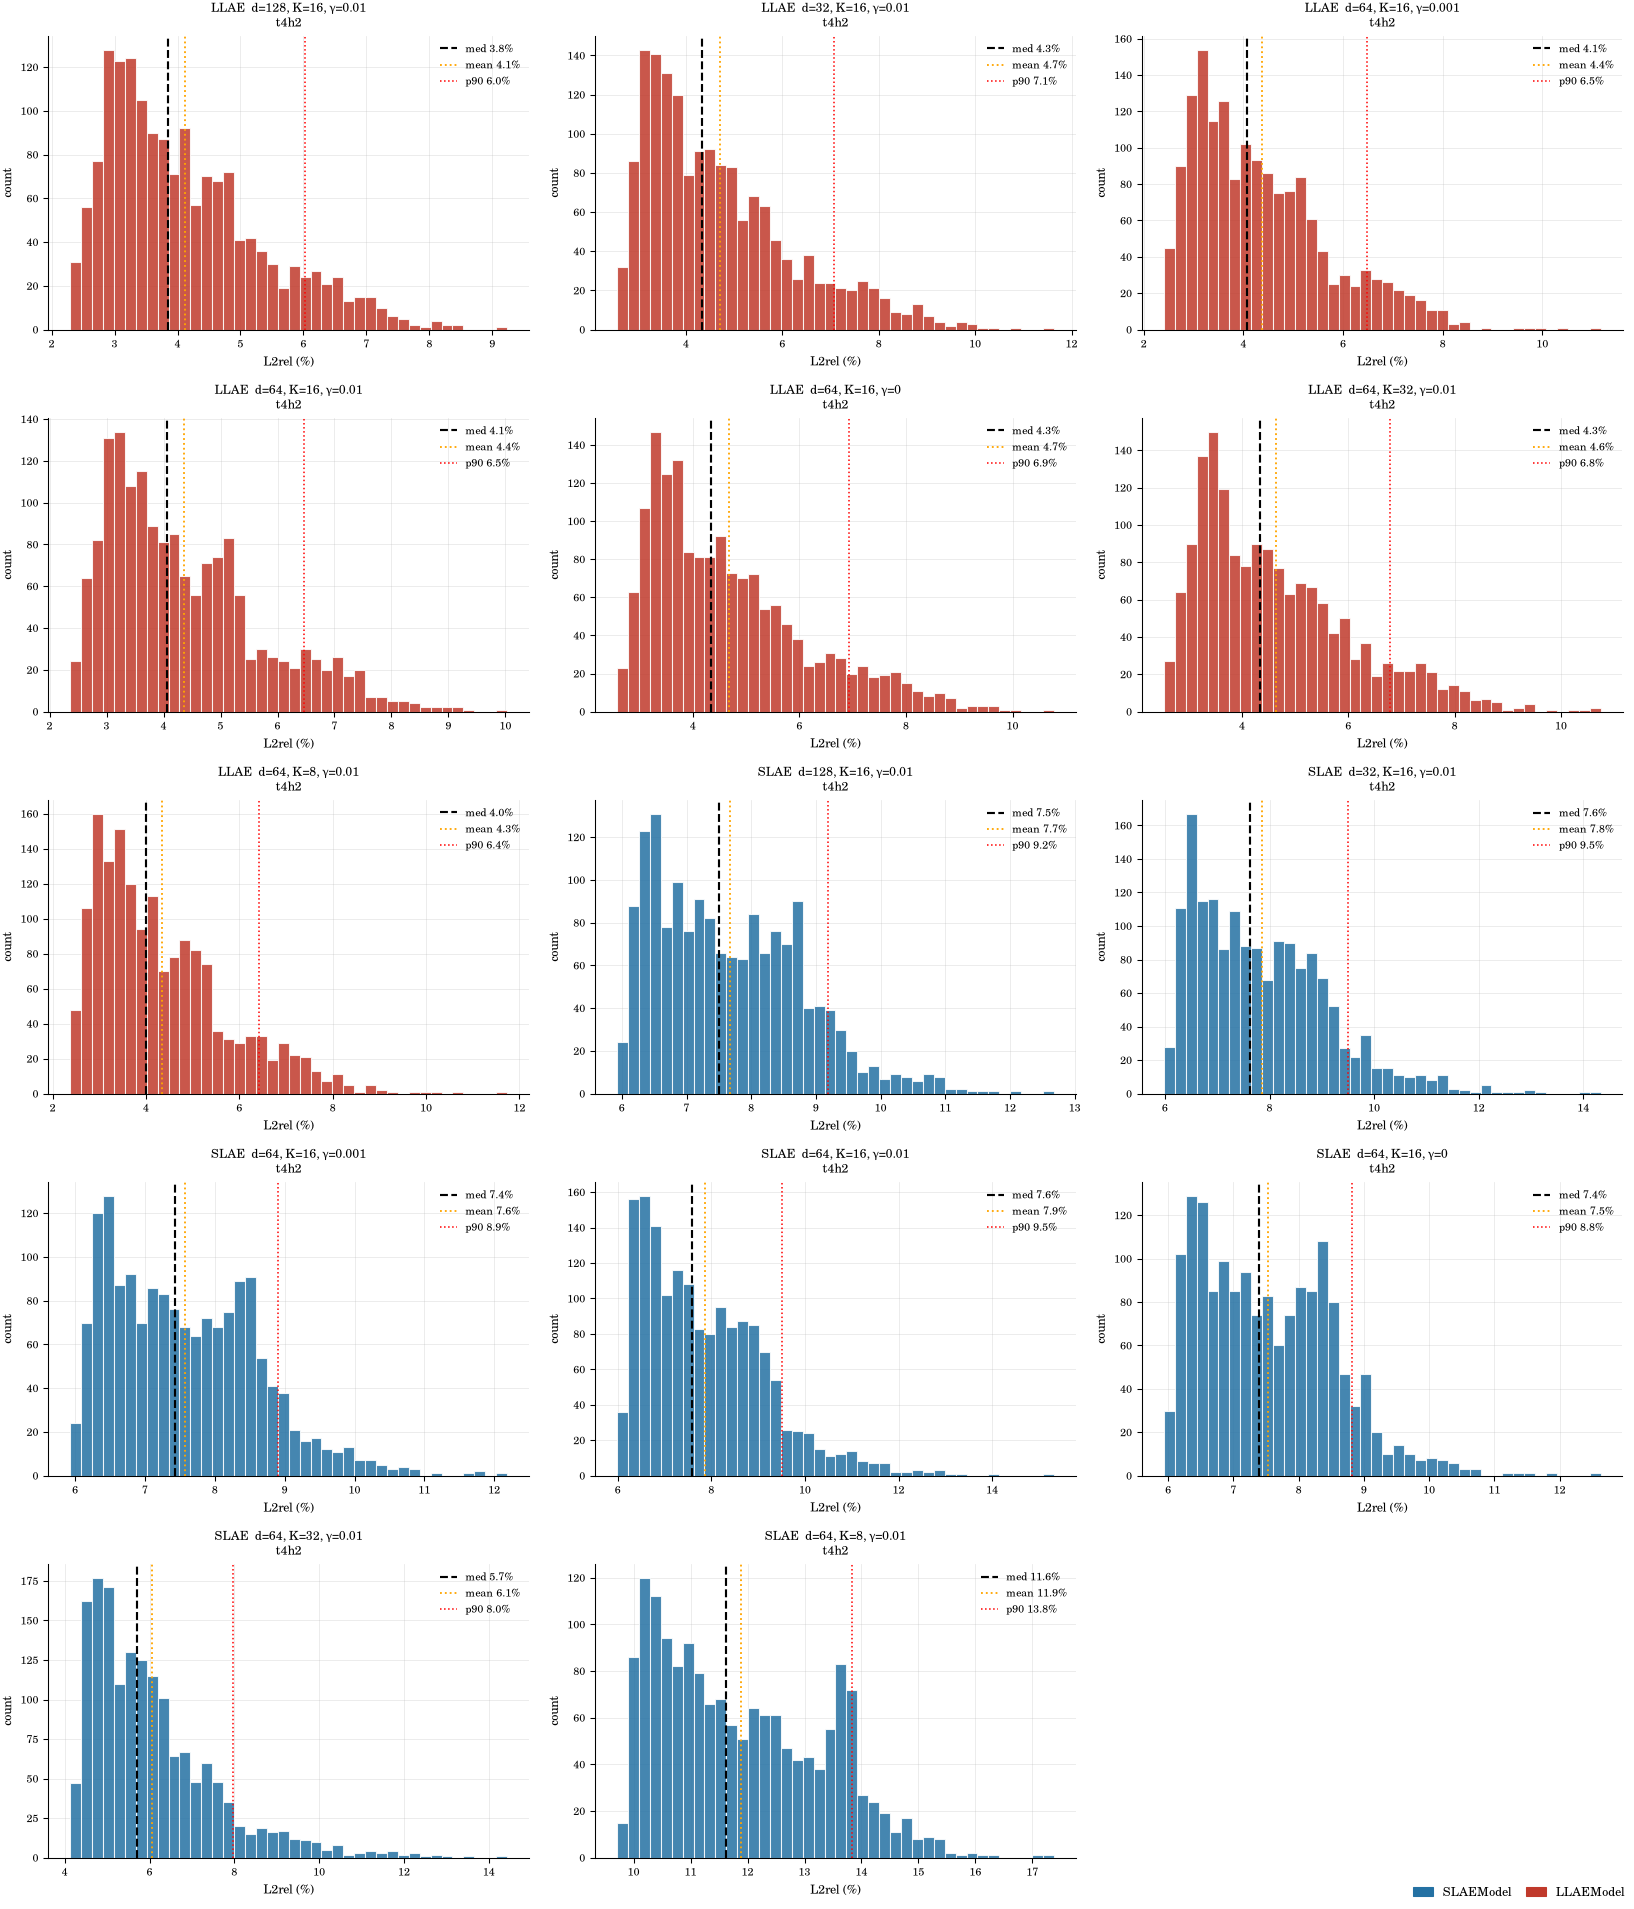

  ↳ article/images/surr_hist_grid.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/surr_hist_grid.pdf')

In [10]:

if results:
    names  = list(results.keys())
    n_ckpt = len(names)
    ncols  = min(3, n_ckpt)
    nrows  = (n_ckpt + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    if n_ckpt == 1:
        axes = np.array([axes])
    axes = np.array(axes).flatten()

    for ax, name in zip(axes, names):
        l2     = results[name]
        mtype  = model_types.get(name, 'SLAEModel')
        color  = PALETTE.get(mtype, 'gray')
        median = np.median(l2)
        mean   = np.mean(l2)
        p90    = np.percentile(l2, 90)

        ax.hist(l2, bins=40, color=color, edgecolor='white', alpha=0.85)
        ax.axvline(median, color='black',  linestyle='--', linewidth=1.4, label=f'med {median:.1f}%')
        ax.axvline(mean,   color='orange', linestyle=':',  linewidth=1.2, label=f'mean {mean:.1f}%')
        ax.axvline(p90,    color='red',    linestyle=':',  linewidth=1.0, label=f'p90 {p90:.1f}%')
        ax.set_title(_pretty_name(name), fontsize=8)
        ax.set_xlabel('L2rel (%)', fontsize=8)
        ax.set_ylabel('count', fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

    for ax in axes[n_ckpt:]:
        ax.set_visible(False)

    from matplotlib.patches import Patch
    legend_handles = [Patch(color=c, label=k) for k, c in PALETTE.items() if k in model_types.values()]
    fig.legend(handles=legend_handles, loc='lower right', fontsize=8, ncol=2)

    fig.suptitle('L2rel on physical field U — surrogate prediction (test set)', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.show()
else:
    print('No surrogate checkpoints found in', CKPT_DIR)
figstyle.save("hist_grid")


## 6. Median comparison

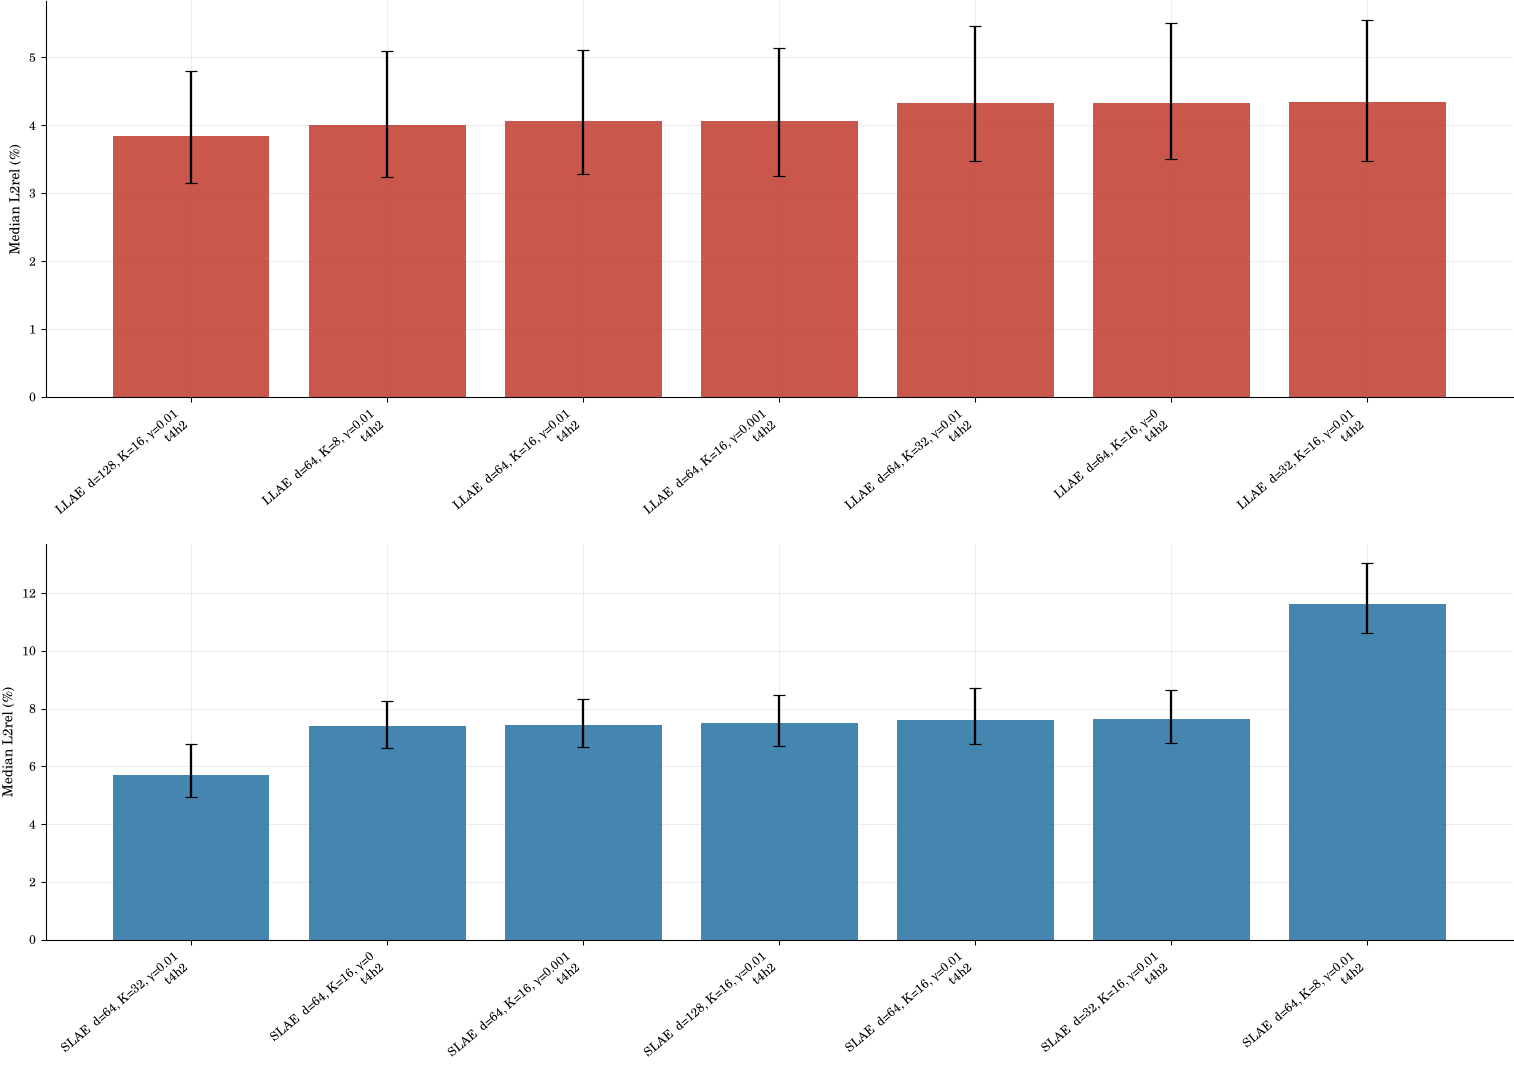

  ↳ article/images/surr_bar_all.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/surr_bar_all.pdf')

In [11]:
if results:
    medians = {n: float(np.median(v)) for n, v in results.items()}
    p25     = {n: float(np.percentile(v, 25)) for n, v in results.items()}
    p75     = {n: float(np.percentile(v, 75)) for n, v in results.items()}

    families = sorted(set(model_types.values()))
    fig, axes = plt.subplots(len(families), 1, figsize=(14, 5 * len(families)))
    if len(families) == 1:
        axes = [axes]

    for ax, family in zip(axes, families):
        names_fam    = [n for n in results if model_types.get(n) == family]
        sorted_names = sorted(names_fam, key=lambda n: medians[n])
        color        = PALETTE.get(family, 'gray')
        x            = np.arange(len(sorted_names))

        ax.bar(x, [medians[n] for n in sorted_names], color=color, alpha=0.85, zorder=2)

        yerr_low  = [medians[n] - p25[n] for n in sorted_names]
        yerr_high = [p75[n] - medians[n] for n in sorted_names]
        ax.errorbar(x, [medians[n] for n in sorted_names],
                    yerr=[yerr_low, yerr_high],
                    fmt='none', color='black', capsize=4, linewidth=1.5, zorder=3)

        ax.set_xticks(x)
        ax.set_xticklabels([_pretty_name(n) for n in sorted_names],
                           rotation=40, ha='right', fontsize=8)
        ax.set_ylabel('Median L2rel (%)')
    
    fig.suptitle('Surrogate checkpoint comparison', fontweight='bold', fontsize=12)
    fig.tight_layout()
    plt.show()
figstyle.save("bar_all")


## 7. Summary table

In [12]:
if results:
    print(f"{'Config':<60}  {'type':<15}  {'median':>8}  {'mean':>8}  {'p90':>8}  {'n':>5}")
    print('-' * 150)
    for n in sorted(results, key=lambda n: np.median(results[n])):
        l2    = results[n]
        mtype = model_types.get(n, '?')
        label = _pretty_name(n).replace('\n', '  ')
        print(f'{label:<60}  {mtype:<15}  {np.median(l2):>7.2f}%  {np.mean(l2):>7.2f}%  '
              f'{np.percentile(l2,90):>7.2f}%  {len(l2):>5}')

Config                                                        type               median      mean       p90      n
------------------------------------------------------------------------------------------------------------------------------------------------------
LLAE  d=128, K=16, γ=0.01  t4h2                               LLAEModel           3.84%     4.12%     6.03%   1620
LLAE  d=64, K=8, γ=0.01  t4h2                                 LLAEModel           4.01%     4.34%     6.42%   1620
LLAE  d=64, K=16, γ=0.01  t4h2                                LLAEModel           4.06%     4.37%     6.47%   1620
LLAE  d=64, K=16, γ=0.001  t4h2                               LLAEModel           4.07%     4.37%     6.48%   1620
LLAE  d=64, K=32, γ=0.01  t4h2                                LLAEModel           4.33%     4.63%     6.79%   1620
LLAE  d=64, K=16, γ=0  t4h2                                   LLAEModel           4.34%     4.68%     6.93%   1620
LLAE  d=32, K=16, γ=0.01  t4h2              

## 8. Family ablation plots

Violin plots showing the effect of each hyperparameter, grouping by model family.

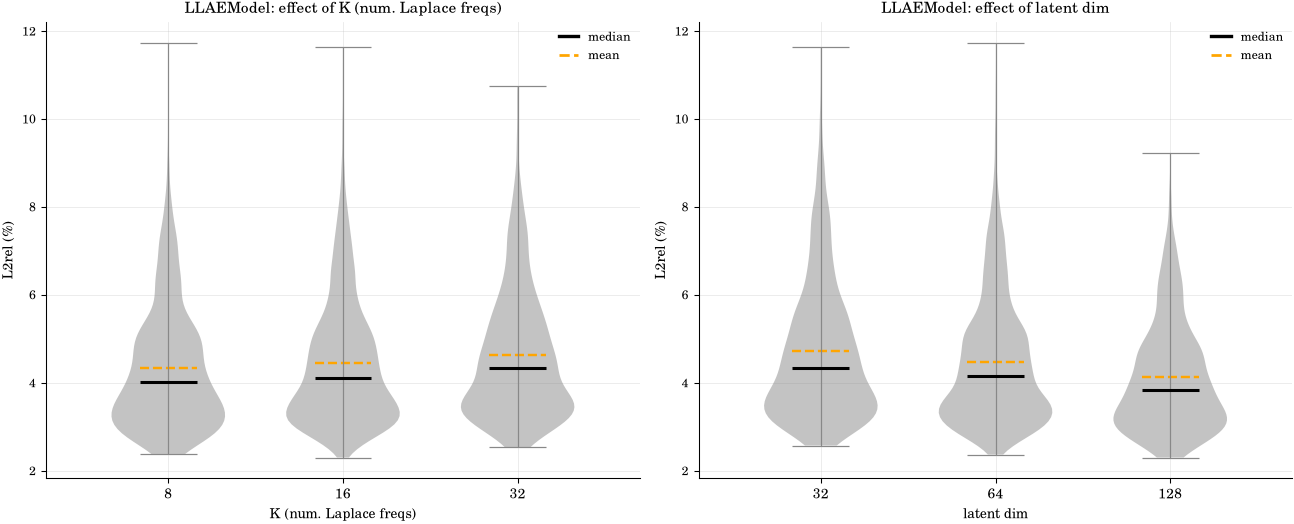

  ↳ article/images/surr_violins_llae.pdf


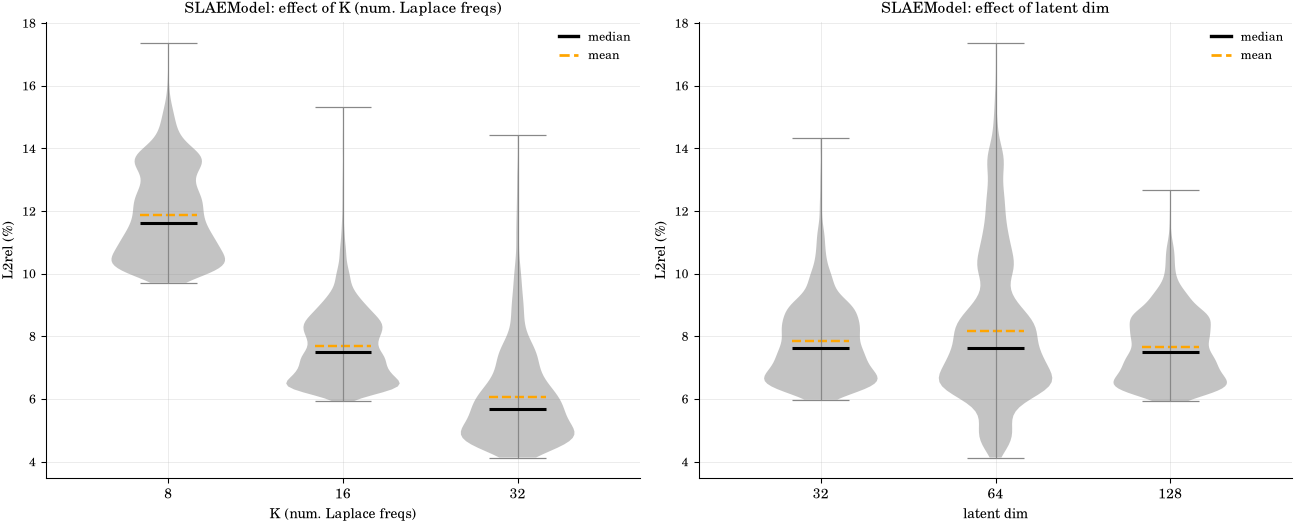

  ↳ article/images/surr_violins_slae.pdf


In [13]:
from collections import defaultdict
from matplotlib.lines import Line2D

# Parse surrogate checkpoint name into structured dict
def _parse_surr_name(name: str) -> dict | None:
    m = _SURR_PAT.match(name)
    if not m:
        return None
    ae_stem = m.group('ae_stem')
    cls     = m.group('cls')

    ae_m = re.match(r'^(?P<ae>[a-z]+)_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<ae_suf>.*)', ae_stem)
    if not ae_m:
        return None

    return {
        'name'   : name,
        'cls'    : cls,
        'ae'     : ae_m.group('ae'),
        'ld'     : int(ae_m.group('ld')),
        'K'      : int(ae_m.group('K')),
        'gamma'  : float(ae_m.group('g')),
        'n_trunk': int(m.group('n_trunk')),
        'n_head' : int(m.group('n_head')),
    }

parsed_rows = [r for r in (_parse_surr_name(n) for n in results) if r is not None]


def _violin_ablation(ax, rows, var_name, xlabel, title):
    """Draw one violin per value of `var_name`."""
    if not rows:
        ax.set_title(f"{title}\n(no data)"); ax.axis('off'); return

    xs_vals = sorted(set(r[var_name] for r in rows))

    legend_handles = [
        Line2D([0], [0], color='black',  linewidth=2.2,              label='median'),
        Line2D([0], [0], color='orange', linewidth=1.8, linestyle='--', label='mean'),
    ]

    groups = defaultdict(list)
    for r in rows:
        groups[r[var_name]].extend(results[r['name']].tolist())

    positions = [i for i, v in enumerate(xs_vals) if v in groups]
    datasets  = [groups[v] for v in xs_vals if v in groups]
    if datasets:
        parts = ax.violinplot(datasets, positions=positions, widths=0.65,
                              showmedians=True, showmeans=True, showextrema=True)
        for pc in parts['bodies']:
            pc.set_facecolor('#888888'); pc.set_alpha(0.5)
        parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2.0)
        parts['cmeans'].set_color('orange');  parts['cmeans'].set_linewidth(1.6)
        parts['cmeans'].set_linestyle('--')
        for key in ('cmaxes', 'cmins', 'cbars'):
            parts[key].set_color('#888888'); parts[key].set_linewidth(0.8)

    ax.set_xticks(range(len(xs_vals)))
    ax.set_xticklabels([str(v) for v in xs_vals], fontsize=9)
    ax.set_xlim(-0.7, len(xs_vals) - 0.3)
    ax.legend(handles=legend_handles, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('L2rel (%)')
    ax.grid(alpha=0.3, axis='y')


# One figure per family; ablations: K, ld, n_trunk
families = sorted(set(r['cls'] for r in parsed_rows))

for family in families:
    frows = [r for r in parsed_rows if r['cls'] == family]
    if not frows:
        continue

    ablations = []
    for var, xlabel in [
        ('K',      'K (num. Laplace freqs)'),
        ('ld',     'latent dim'),
        ('n_trunk','n_trunk'),
    ]:
        if len(set(r[var] for r in frows)) > 1:
            ablations.append((var, xlabel))

    if not ablations:
        print(f'{family}: only one configuration found, skipping ablation plot.')
        continue

    fig, axes = plt.subplots(1, len(ablations), figsize=(6 * len(ablations), 5))
    if len(ablations) == 1:
        axes = [axes]

    for ax, (var, xlabel) in zip(axes, ablations):
        _violin_ablation(ax, frows, var, xlabel, f'{family}: effect of {xlabel}')

    fig.suptitle(f'{family} — L2rel distributions (test set)', fontweight='bold')
    fig.tight_layout()
    plt.show()
    figstyle.save("violins_" + str(family).replace("Model", "").lower())


## Error across the design of experiments

The design is factorial: 15 values of $k$ crossed with 15 of $C$ and 36 injection
angles $\phi$, the angle being a numerical rotation of the same base solution. Two
questions follow. Is $\phi$ an easy direction that pulls the aggregate down, and is
the upper tail localised in the physical plane $(k, C)$?

The correlation ratio $\eta^2$ gives the fraction of the error variance explained by
each factor, and the maps show where the $p_{90}$ tail sits.


In [14]:
doe = np.load(DOE_PATH)
k_all, phi_all, C_all = doe['k'], doe['A'], doe['C']   # 'A' holds the injection angle


def eta2(x, y, bins=None):
    """Fraction of Var(y) explained by x (correlation ratio)."""
    g = x if bins is None else np.digitize(
        x, np.quantile(x, np.linspace(0, 1, bins + 1)[1:-1]))
    m = y.mean()
    inter = sum((g == u).sum() * (y[g == u].mean() - m) ** 2 for u in np.unique(g))
    return inter / ((y - m) ** 2).sum()


def doe_factors(name):
    """Errors and design coordinates for a checkpoint, or None if misaligned.

    eval_surrogate drops instances whose norm underflows, so the error array is not
    guaranteed to be in one-to-one correspondence with test_idx. A silent shift would
    produce a plausible but wrong map, so the mismatch is refused rather than trimmed.
    """
    err = np.asarray(results[name], dtype=float)
    if len(err) != len(test_idx):
        print(f'  {name}: {len(err)} errors for {len(test_idx)} test instances '
              f'— misaligned, skipped.')
        return None
    idx = np.asarray(test_idx)
    return err, k_all[idx], phi_all[idx], C_all[idx]


print(f"{'checkpoint':<46}{'eta2 phi':>10}{'eta2 k':>9}{'eta2 C':>9}")
print('-' * 74)
eta_rows = {}
for name in sorted(results, key=lambda n: np.median(results[n])):
    f = doe_factors(name)
    if f is None:
        continue
    err, k, phi, C = f
    eta_rows[name] = (eta2(phi, err), eta2(k, err, bins=8), eta2(C, err, bins=8))
    print(f'{_pretty_name(name):<46}' + ''.join(f'{v:>9.3f} ' for v in eta_rows[name]))


checkpoint                                      eta2 phi   eta2 k   eta2 C
--------------------------------------------------------------------------
LLAE  d=128, K=16, γ=0.01
t4h2                    0.027     0.264     0.529 
LLAE  d=64, K=8, γ=0.01
t4h2                      0.028     0.242     0.568 
LLAE  d=64, K=16, γ=0.01
t4h2                     0.028     0.258     0.572 
LLAE  d=64, K=16, γ=0.001
t4h2                    0.028     0.230     0.583 
LLAE  d=64, K=32, γ=0.01
t4h2                     0.026     0.204     0.652 
LLAE  d=64, K=16, γ=0
t4h2                        0.024     0.190     0.654 
LLAE  d=32, K=16, γ=0.01
t4h2                     0.025     0.215     0.627 
SLAE  d=64, K=32, γ=0.01
t4h2                     0.028     0.149     0.700 
SLAE  d=64, K=16, γ=0
t4h2                        0.035     0.069     0.725 
SLAE  d=64, K=16, γ=0.001
t4h2                    0.034     0.066     0.740 
SLAE  d=128, K=16, γ=0.01
t4h2                    0.032     0.080     0.756 
SLA

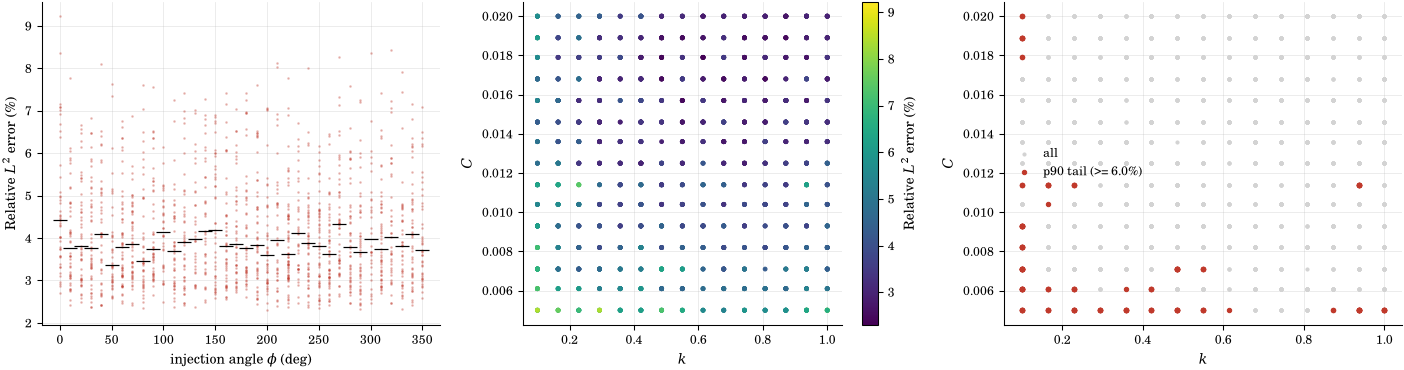

  ↳ article/images/surr_doe_map_llae.pdf


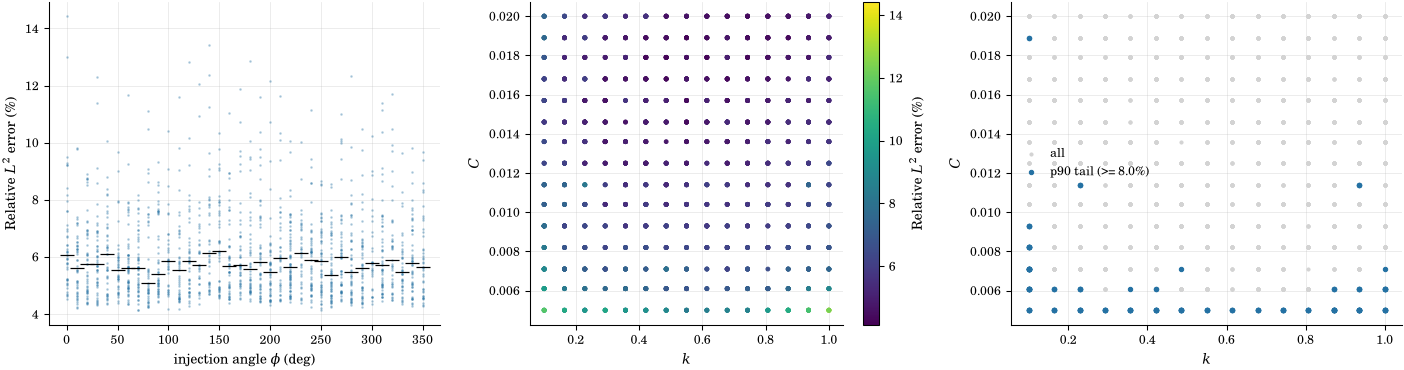

  ↳ article/images/surr_doe_map_slae.pdf


In [15]:
# Map the family-best checkpoint of each family.
best = {}
for name in results:
    fam = model_types.get(name, '')
    if fam and (fam not in best or np.median(results[name]) < np.median(results[best[fam]])):
        best[fam] = name

for fam, name in sorted(best.items()):
    f = doe_factors(name)
    if f is None:
        continue
    err, k, phi, C = f
    col = PALETTE.get(fam, 'gray')

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    axes[0].plot(phi, err, '.', ms=2, alpha=0.25, color=col)
    for u in np.unique(phi):
        axes[0].plot(u, np.median(err[phi == u]), 'k_', ms=9)
    axes[0].set_xlabel(r'injection angle $\phi$ (deg)')
    axes[0].set_ylabel(figstyle.LABELS['l2rel'])

    s = axes[1].scatter(k, C, c=err, s=6, cmap='viridis')
    axes[1].set_xlabel('$k$'); axes[1].set_ylabel('$C$')
    fig.colorbar(s, ax=axes[1], label=figstyle.LABELS['l2rel'])

    q = np.percentile(err, 90)
    axes[2].scatter(k, C, s=4, color='lightgray', label='all')
    axes[2].scatter(k[err >= q], C[err >= q], s=8, color=col,
                    label=f'$p_{{90}}$ tail ($\\geq$ {q:.1f}\\%)' if
                    mpl.rcParams['text.usetex'] else f'p90 tail (>= {q:.1f}%)')
    axes[2].set_xlabel('$k$'); axes[2].set_ylabel('$C$')
    axes[2].legend(fontsize=8)

    fig.tight_layout()
    plt.show()
    figstyle.save('doe_map_' + str(fam).replace('Model', '').lower())


## 9. Inference latency benchmark

In [16]:
import benchmark   # methodologie commune a tous les notebooks

N_BENCH = 200

# Pre-load theta for the benchmark samples (lightweight, no U needed for surrogate)
bench_theta = theta_np[test_idx[:N_BENCH]]   # (N_BENCH, 3)
print(f'Benchmark theta shape: {bench_theta.shape}')

bench = {}

for ckpt_path in tqdm(ckpt_paths, desc='latency benchmark'):
    name = os.path.splitext(os.path.basename(ckpt_path))[0]
    try:
        pipe  = InferencePipeline.from_checkpoint(ckpt_path, device=device)
        theta_dev = torch.tensor(bench_theta[:1], dtype=torch.float32, device=device)
        theta_mean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
        theta_std  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)
        theta_norm = (theta_dev - theta_mean) / theta_std

        def lat_fn():
            with torch.no_grad():
                pipe.model.generate(theta_norm)

        bench[name] = benchmark.measure(lat_fn, device, name=name)

        pipe.model.cpu(); del pipe
        if device == 'cuda': torch.cuda.empty_cache()
        gc.collect()

    except Exception as e:
        print(f'{name}  ERROR: {e}')

print('\nDone.')

Benchmark theta shape: (200, 3)


latency benchmark:   0%|          | 0/14 [00:00<?, ?it/s]

/tmp/ipykernel_584488/4243477914.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_mean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
/tmp/ipykernel_584488/4243477914.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta_std  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)


latency benchmark:   7%|▋         | 1/14 [00:04<01:00,  4.64s/it]

LLAEModel__llae_ld128_K16_g0.01__t4h2         lat=   22.4±  3.1 ms  flops=  48.5 G  mem=   662 MB  E=2178.1 mJ


...

latency benchmark:  93%|█████████▎| 13/14 [00:41<00:02,  2.98s/it]

SLAEModel__slae_ld64_K32_g0.01__t4h2          lat=   23.6±  0.7 ms  flops=  60.7 G  mem=   392 MB  E=2529.8 mJ


latency benchmark: 100%|██████████| 14/14 [00:44<00:00,  2.83s/it]

latency benchmark: 100%|██████████| 14/14 [00:44<00:00,  3.14s/it]

SLAEModel__slae_ld64_K8_g0.01__t4h2           lat=   12.1±  0.1 ms  flops=  15.2 G  mem=   159 MB  E=1288.1 mJ

Done.


checkpoint                                       lat (ms)       ±   FLOPs (G)   mem (MB)    E (mJ)
--------------------------------------------------------------------------------------------------
SLAE  d=64, K=8, γ=0.01
t4h2                         12.1     0.1        15.2        159    1288.1
SLAE  d=32, K=16, γ=0.01
t4h2                        15.7     0.3        30.3        209    1703.9
SLAE  d=128, K=16, γ=0.01
t4h2                       15.7     0.3        30.4        287    1687.9
SLAE  d=64, K=16, γ=0.001
t4h2                       15.7     0.3        30.3        235    1688.8
SLAE  d=64, K=16, γ=0
t4h2                           15.8     0.3        30.3        235    1695.6
SLAE  d=64, K=16, γ=0.01
t4h2                        15.8     0.4        30.3        235    1712.7
LLAE  d=128, K=16, γ=0.01
t4h2                       22.4     3.1        48.5        662    2178.1
LLAE  d=64, K=16, γ=0.001
t4h2                       22.8     3.5        48.2        622    2891.1
LLAE  d=64

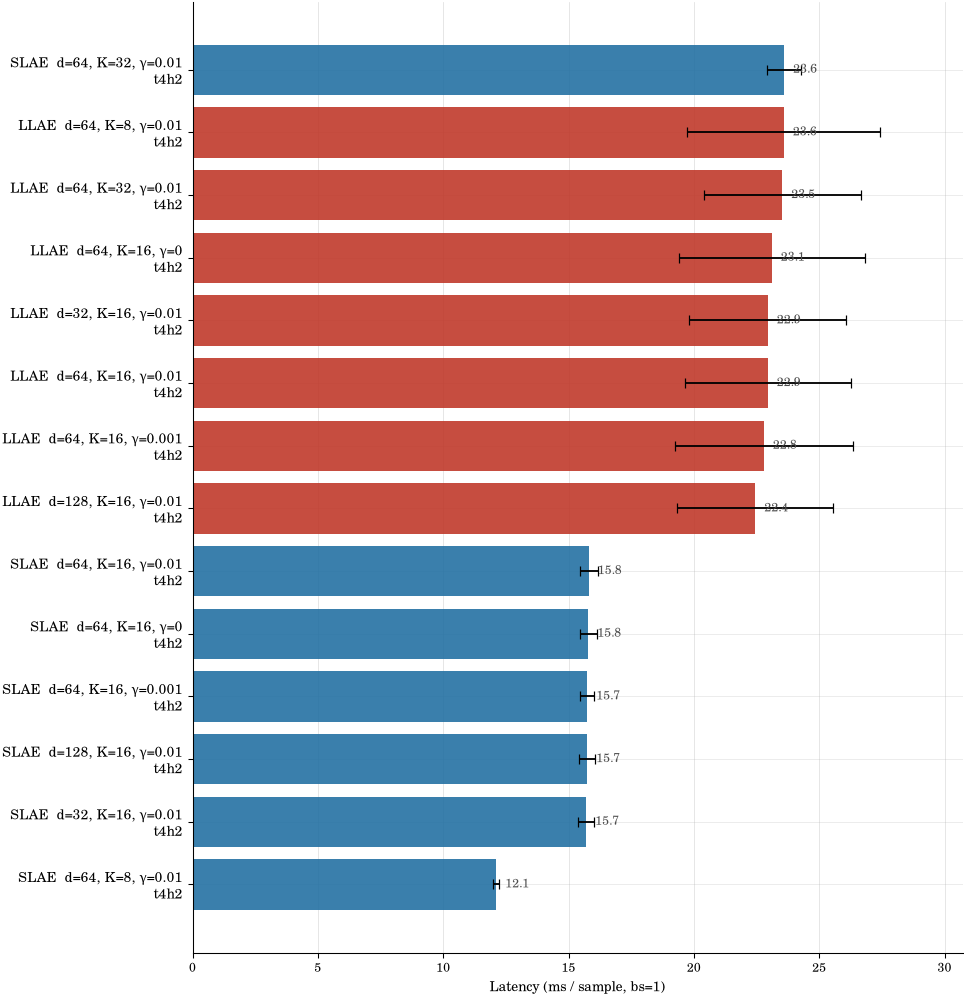

  ↳ article/images/surr_bench_latency.pdf


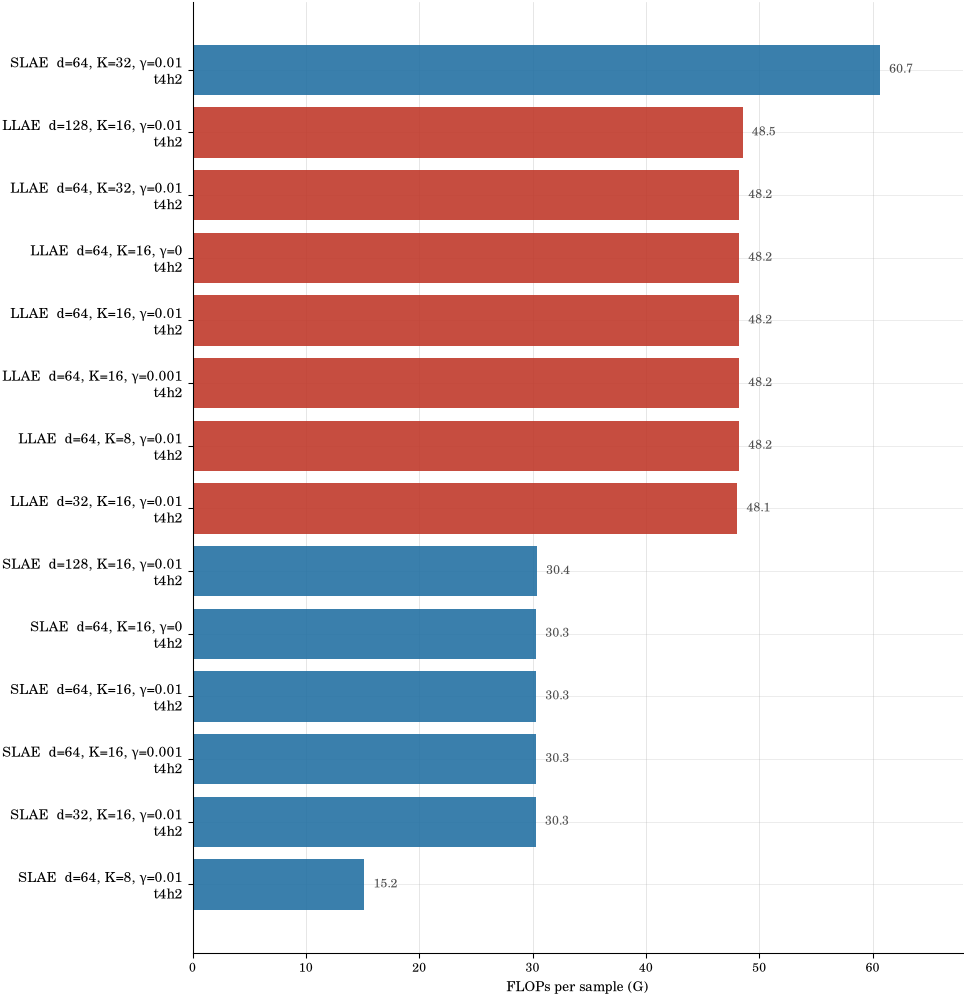

  ↳ article/images/surr_bench_flops.pdf


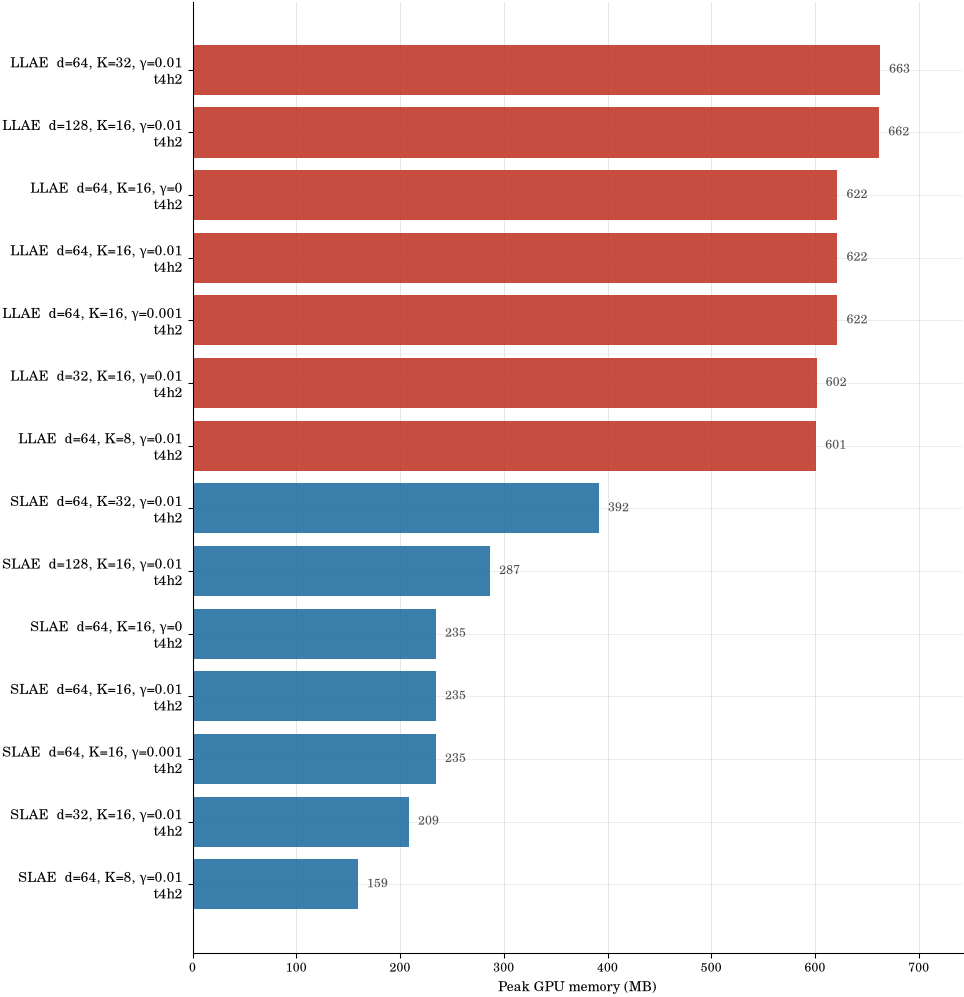

  ↳ article/images/surr_bench_memory.pdf


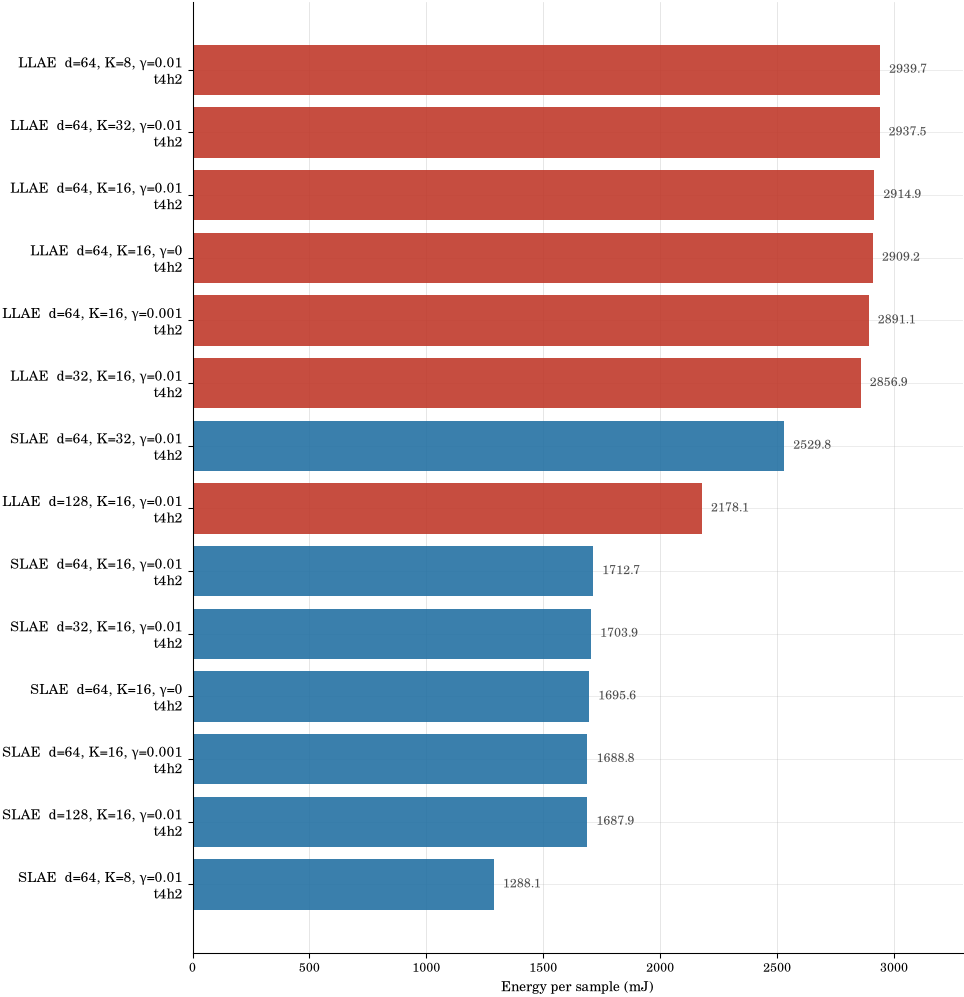

  ↳ article/images/surr_bench_energy.pdf


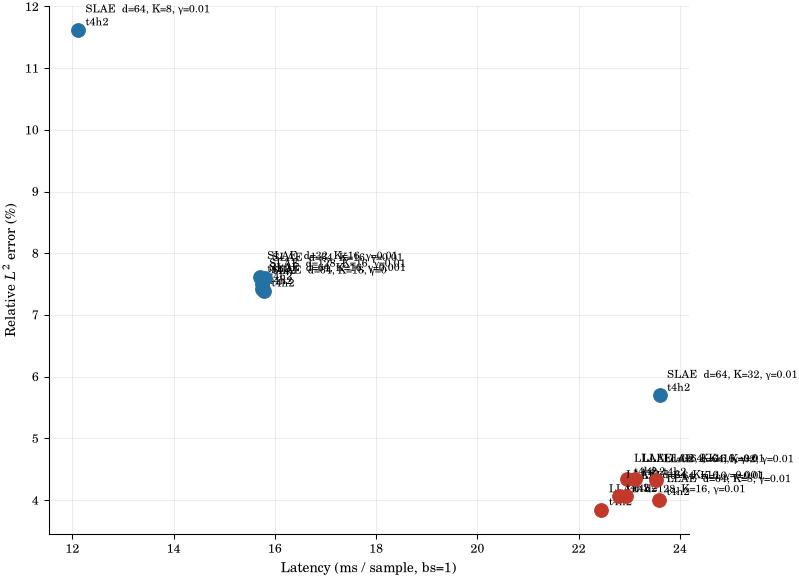

  ↳ article/images/surr_cost_latency.pdf


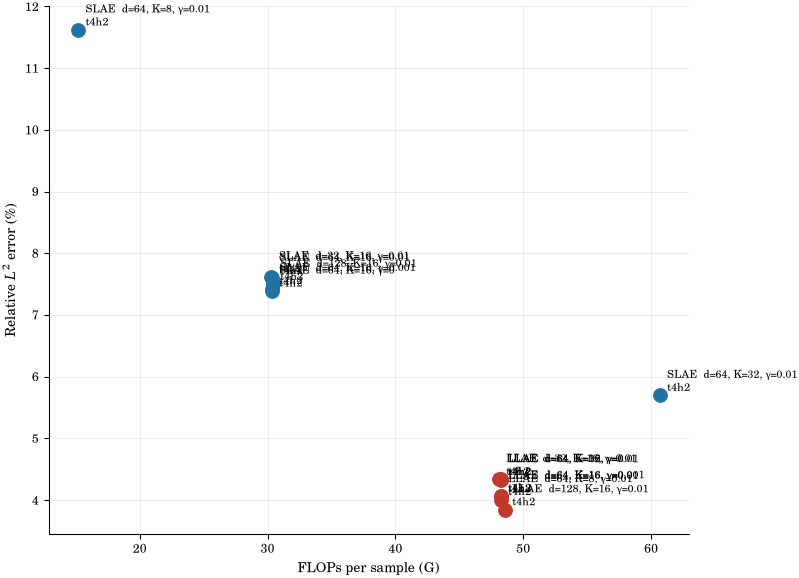

  ↳ article/images/surr_cost_flops.pdf


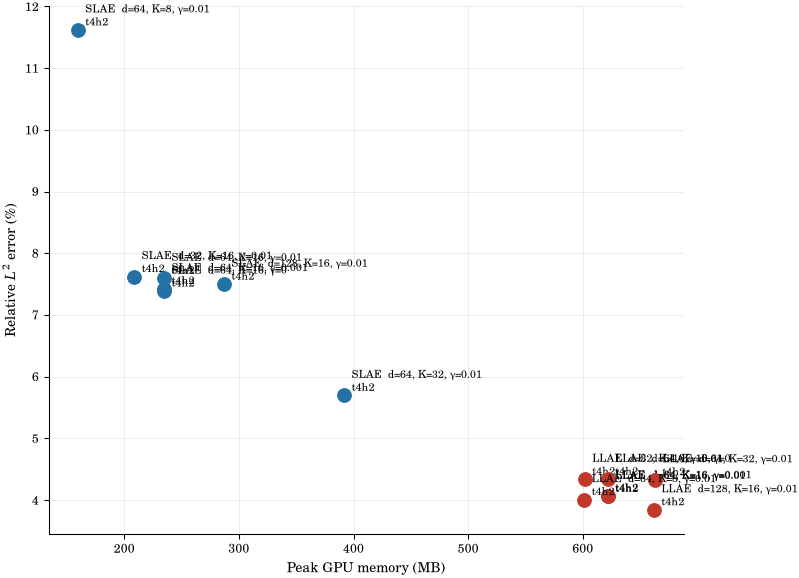

  ↳ article/images/surr_cost_memory.pdf


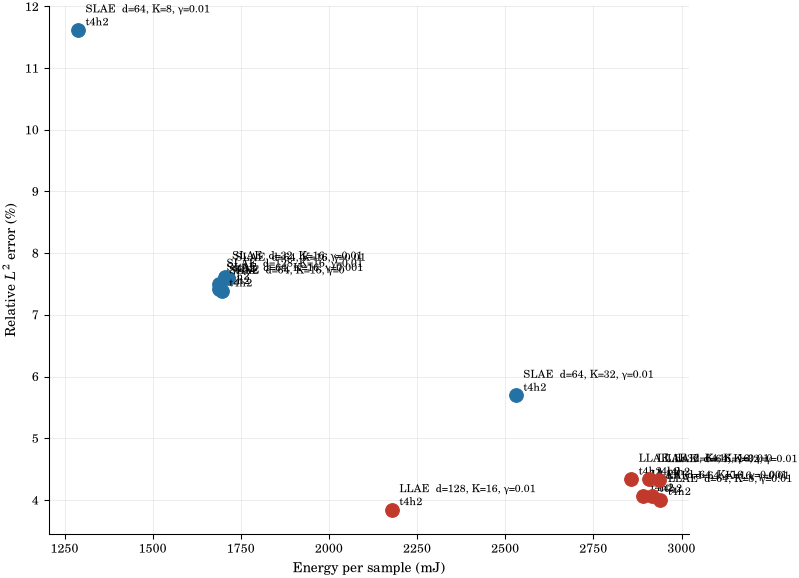

  ↳ article/images/surr_cost_energy.pdf


['cost_latency', 'cost_flops', 'cost_memory', 'cost_energy']

In [17]:
# One figure per metric, plus the matching accuracy/cost scatter.
def _bench_color(n):
    return PALETTE.get(model_types.get(n, ''), 'gray')

benchmark.table(bench, label_of=_pretty_name)

benchmark.figures(bench, label_of=_pretty_name, color_of=_bench_color, device=device)

_acc = {n: float(np.median(results[n])) for n in results if n in bench}
benchmark.scatter(bench, _acc, label_of=_pretty_name, color_of=_bench_color,
                  device=device, ylabel=figstyle.LABELS['l2rel'])
